# PROJECT TITLE GOES HERE

## 2024-25 Group: X

*This is the MN5813 Assignment*

- Student ID


## Project summary

In [1]:
# Add your project summary here [app. 200-250 words]

## Generative AI

In [2]:
# Add your statement / declaration here [be as specific as possible]

## Introduction

In [3]:
# Add your introduction here [app. 200-300 words]
# Formulate project aim & set of objectives

## Data Sources

#### Dataset Selection

**1. Main Dataset:** Full TMDB Movies Dataset 2024 (1M Movies)

The TMDb (The Movie Database) is a comprehensive movie database that provides information about movies, including details like titles, ratings, release dates, revenue, genres, and much more. Updated Daily

**Data Source:** https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/data

#### Justification

The TMDB dataset was selected for the following reasons:

1. **Comprehensive Coverage:** Contains 1 million + movies spanning from the silent era to contemporary releases, enabling analysis across nearly a century of film history.
2. **Revenue Data:** Includes box office revenue figures, a quantifiable metric for audience engagement and commercial success.
3. **Genre Classification:** Provides genre metadata for films, enabling categorical analysis of preference patterns.
4. **Reliability:** TMDB is a widely used, professionally maintained database with community contributions and editorial oversight.
5. **Accessibility:** Freely available via Kaggle, facilitating reproducible research and transparent methodology.
   

**2. Additional Dataset:** Consumer Price Index from U.S. Bureau of Labor Statistics

Data was taken from this **Data Sourse**: https://data.bls.gov/timeseries/CUUR0000SA0

Comparing box office revenues across nearly a century presents a fundamental analytical challenge: the purchasing power of currency changes dramatically over time. A film earning £10 million in 1950 represents vastly different commercial success than one earning £10 million in 2023. For example, it is incorrect to compare the \$5 million revenue of *Gone with the Wind* (1939) with the \$2 billion of *Avatar*.

**Solution: CPI-based inflation adjustment**

The Consumer Price Index (CPI), sourced from the U.S. Bureau of Labor Statistics, provides a standardised measure of price changes across time. By converting all revenues to 2023 equivalent values, we achieve temporal comparability.

## Methodology

### Era Classification

Films are categorised into four distinct cinematic eras:

1. **Golden Age of Hollywood (1927-1950):** Dominance of musicals, dramas, and noir
2. **Age of Television Competition (1950-1970):** Epic films and Westerns
3. **Era of First Blockbusters (1970-2000):** Rise of Sci-Fi and action films
4. **Modern Era of Franchises (2000-2023):** Reign of superheroes and animation

### Genre Processing and Revenue Allocation Methodology

**Genre Processing:** Since films in TMDB are classified with multiple genres, we employ **equal proportional revenue allocation** to ensure each genre receives its fair share of the film's revenue without double-counting or distortion.

**Example:** 
- Film: *Inception* (2010)
- Revenue (2023 USD): $1,153.56 million
- Genres: Action, Science Fiction, Adventure (3 genres)
- Allocation per genre: $1,153.56 ÷ 3 = $384.52 million per genre

**Rationale:** This approach ensures:
1. **No double-counting:** Total genre revenues sum to actual box office total
2. **Fairness:** Each genre contributes equally (assumes equal appeal)
3. **Accuracy:** Prevents inflating total market size
4. **Temporal consistency:** Total revenue by era equals actual box office total for that era

This method is superior to alternatives:
- **Full attribution:** Would inflate totals
- **Primary genre only:** Would lose multi-genre information
- **Weighted by position:** Would require subjective weighting

###  CPI for Inflation adjustment

[this section need more info]

## Main Dataset Raw Data Loading

[Data set](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/data) is quite big (585 MB) and updated daily, so I decided to download it and pre clean it by removing unnecessary columns in order to work with smaller size file that I can put on GitHub. 

[*The TMDB Movies Dataset (1M Movies) is a substantial resource containing comprehensive 
information about films spanning nearly a century. The original file (585 MB) contains 
approximately 1 million movies with numerous metadata fields. However, for this analysis, 
only five columns are essential: title, genres, releasedate, budget, revenue, and movie I*]

**Rationale for column selection:** This focused approach reduces file size, minimises memory 
usage, and enables efficient processing while retaining all variables necessary for examining 
genre preferences through box office performance (revenue) and temporal patterns (release date]).

D. 

 

Zip file was downloaded from Kaggle to my laptop. 

I extract zip file and find 
- `TMDB_movie_dataset_v11` csv file. 

Here is a code that was used for cutting initial raw data set *Full TMDB Movies Dataset 2024 (1M Movies)*:

Uncomment if nessesary to run the code

In [4]:
#import pandas as pd
#df = pd.read_csv("archive/TMDB_movie_dataset_v11.csv")

#print(f"Dataset 'TMDB_movie_dataset' loaded: {len(df)} rows, {len(df.columns)} columns")
#print(f"\nColumn names:\n{list(df.columns)}")

In [5]:
# Keep only the columns needed in the specified order
#columns_to_keep = ['title', 'genres', 'release_date', 'budget', 'revenue', 
#                   'vote_average', 'vote_count', 'popularity', 'id']
#df = df[columns_to_keep]

#print(f"Dataset 'TMDB_movie_dataset' loaded: {len(df)} rows, {len(df.columns)} columns")
#print(f"\nColumn names:\n{list(df.columns)}")

#print("Dataset information:")
#df.info()

In [6]:
# Check missing/problematic values before cleaning
#print("Before cleaning:")
#print(f"Total rows: {len(df)}")
#print(f"Missing release_date: {df['release_date'].isnull().sum()}")
#print(f"Empty genres: {(df['genres'] == '[]').sum()}")
#print(f"Zero budget: {(df['budget'] == 0).sum()}")
#print(f"Zero revenue: {(df['revenue'] == 0).sum()}")

# Drop rows with missing release_date
#df = df.dropna(subset=['release_date'])

# Drop rows with empty genres (usually stored as '[]')
#df = df[df['genres'] != '[]']

# Drop rows with zero or missing budget
#df = df[df['budget'] > 0]

# Drop rows with zero or missing revenue
#df = df[df['revenue'] > 0]

# Reset index after dropping rows
#df = df.reset_index(drop=True)

# Check results after cleaning
#print("\nAfter cleaning:")
#print(f"Total rows: {len(df)}")
#print(df.info())

In [7]:
# Save pre cleaned Data to a new CSV file
#output_filename = 'raw_data_precleaned.csv'
#df.to_csv(output_filename, index=False)

Going on I will work with precleaned data set

- `raw_data_precleaned.csv`

I add it to my GitHUb repository

url = 'https://github.com/GroupProjectMN5813-lab/Individual-Report/blob/main/raw_data_precleaned.csv'

## Environment Setup and Library Imports

Before beginning analysis, we import the necessary Python libraries that enable data manipulation, numerical computation, and visualisation:

- **pandas**: For data manipulation, filtering, and aggregation
- **numpy**: For numerical operations and array handling
- **matplotlib & seaborn**: For creating publication-quality visualisations
- **datetime**: For handling date-based operations
- **warnings**: To suppress non-critical warning messages for cleaner output

We also configure pandas display settings to show complete information without truncation, ensuring that data inspection is comprehensive and transparent throughout the analysis process.

In [8]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Set display options for better output
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

In [9]:
# Load main dataset directly from GitHub (This code works (06.01)
#url = 'https://raw.githubusercontent.com/GroupProjectMN5813-lab/Individual-Report/main/raw_data_precleaned.csv'
#df = pd.read_csv(url)

#print(df.info())
#print(df.head())

# So far while I work on the project I will use hard path

The precleaned dataset is loaded directly from GitHub, ensuring reproducibility and transparency. This approach allows anyone accessing this notebook to obtain the identical dataset without manual intervention.

### Convert into DataFrame

I use `pd.read_csv()` to convert data into Pandas DataFrames. 

In [10]:
# So far while I work on the project I use hard path
df = pd.read_csv("assets/data/raw_data_precleaned.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13548 entries, 0 to 13547
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         13548 non-null  object 
 1   genres        13066 non-null  object 
 2   release_date  13548 non-null  object 
 3   budget        13548 non-null  int64  
 4   revenue       13548 non-null  int64  
 5   vote_average  13548 non-null  float64
 6   vote_count    13548 non-null  int64  
 7   popularity    13548 non-null  float64
 8   id            13548 non-null  int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 952.7+ KB
None


Now we need to Display the first few rows and basic information about the DataFrame `df` that was created from `data_source`.

In [11]:
df.head()

,title,genres,release_date,budget,revenue,vote_average,vote_count,popularity,id
0,Inception,"Action, Science Fiction, Adventure",2010-07-15,160000000,825532764,8.364,34495,83.952,27205
1,Interstellar,"Adventure, Drama, Science Fiction",2014-11-05,165000000,701729206,8.417,32571,140.241,157336
2,The Dark Knight,"Drama, Action, Crime, Thriller",2008-07-16,185000000,1004558444,8.512,30619,130.643,155
3,Avatar,"Action, Adventure, Fantasy, Science Fiction",2009-12-15,237000000,2923706026,7.573,29815,79.932,19995
4,The Avengers,"Science Fiction, Action, Adventure",2012-04-25,220000000,1518815515,7.710,29166,98.082,24428


### Initial exploration

We start by exploring our data to understand its structure, contents, and quality.

First We want to know how many rows and columns in our data set and names of the columns. 

We use `len(data_frame)` to find how many rows in our data sets; `len(data_frame.columns)` to find the number of columns and `list(data_frame.columns)` to list names of all the columns in our data sets.

In [12]:
print(f"Dataset 'tmdb_movies' loaded: {len(df)} rows, {len(df.columns)} columns")
print(f"\nColumn names:\n{list(df.columns)}")

Dataset 'tmdb_movies' loaded: 13548 rows, 9 columns

Column names:
['title', 'genres', 'release_date', 'budget', 'revenue', 'vote_average', 'vote_count', 'popularity', 'id']


**DataFrame inspection reveals:**
- 13,548 rows (films) and 9 columns (features)
- Column composition: title, genres, release_date, budget, revenue, vote_average, vote_count,   popularity and ID
- Data types are predominantly integer (budget, revenue, votecount, ID) and float (vote average, popularity), with object types for categorical data (title, genres, release_date)

This inspection is critical because it establishes a understanding of data structure before any transformations are applied.

## Data management

## Data cleaning

#### Addressing Data Quality Issues

Data cleaning is a critical phase that ensures the reliability of subsequent analysis. This section addresses missing values, duplicates, and data type inconsistencies. 

### Assessing and handling Missing Values

Data quality is fundamental to analytical integrity. Missing values (represented as NaN in 
pandas) can distort frequency counts, revenue aggregations, and genre classifications,
leading to biased conclusions about cinematic preferences.

Understanding the extent and distribution of missing values is essential for deciding on appropriate handling strategies.

In [13]:
# Count missing values
missing_count = df.isnull().sum()

# Calculate percentage of missing values
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percent': missing_percent
})

# Sort by missing count (descending) to see the worst columns first
missing_summary = missing_summary.sort_values('Missing_Count', ascending=False)

print("Missing values summary:")
print(missing_summary)

# Only show columns with missing values
print("\nColumns with missing values:")
print(missing_summary[missing_summary['Missing_Count'] > 0])

Missing values summary:
              Missing_Count  Missing_Percent
genres                  482             3.56
title                     0             0.00
release_date              0             0.00
budget                    0             0.00
revenue                   0             0.00
vote_average              0             0.00
vote_count                0             0.00
popularity                0             0.00
id                        0             0.00

Columns with missing values:
        Missing_Count  Missing_Percent
genres            482             3.56


**Missing value assessment results:**
- genres: 482 missing entries (3.56% of dataset)
- All other columns: complete with no missing values

The genres column contains the critical information needed for this analysis. Records without genre classification cannot meaningfully contribute to our investigation of genre preferences. 
Therefore, these 482 records will be removed.

**Impact:** This represents a minimal loss of approximately 3.6% of the dataset, ensuring data quality whilst preserving analytical power.

In [14]:
# Create a copy for cleaning
df_clean = df.copy()

print(f'Original dataset size: {len(df_clean)} rows')

# Remove rows with missing genres 
df_clean = df_clean.dropna(subset=['genres'])
print(f'After removing missing genres: {len(df_clean)} rows')


Original dataset size: 13548 rows
After removing missing genres: 13066 rows


In [15]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 13066 entries, 0 to 13547
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         13066 non-null  object 
 1   genres        13066 non-null  object 
 2   release_date  13066 non-null  object 
 3   budget        13066 non-null  int64  
 4   revenue       13066 non-null  int64  
 5   vote_average  13066 non-null  float64
 6   vote_count    13066 non-null  int64  
 7   popularity    13066 non-null  float64
 8   id            13066 non-null  int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 1020.8+ KB
None


### Handling Duplicates

Duplicate records can artificially inflate genre frequencies, overstate revenue aggregations, create spurious patterns in temporal analysis, leading to biased analysis.

Two types of duplication are examined:

- Complete duplicates (all columns identical)
- Title-date duplicates: records with identical titles and release dates but differing other columns

In [16]:
# Check for complete duplicate rows (all columns identical)
complete_duplicates = df_clean.duplicated().sum()
print(f"Complete duplicate rows (all columns identical): {complete_duplicates}")

if complete_duplicates > 0:
    print("\nShowing complete duplicate rows:")
    print(df_clean[df_clean.duplicated(keep=False)].sort_values('title'))

print("\n" + "="*60 + "\n")

# Check for duplicates based on title and release_date
title_date_duplicates = df_clean.duplicated(subset=['title', 'release_date']).sum()
print(f"Duplicates based on title + release_date: {title_date_duplicates}")

if title_date_duplicates > 0:
    print("\nShowing duplicates based on title and release_date:")
    duplicate_movies = df_clean[df_clean.duplicated(subset=['title', 'release_date'], keep=False)]
    print(duplicate_movies.sort_values(['title', 'release_date'])[['title', 'release_date', 'budget', 'revenue', 'id']])

print("\n" + "="*60 + "\n")

Complete duplicate rows (all columns identical): 0


Duplicates based on title + release_date: 16

Showing duplicates based on title and release_date:
                                                   title release_date  \
12402                                    2 guys fighting   2025-04-15   
12403                                    2 guys fighting   2025-04-15   
11036                                 Apocalypse Unknown   2022-08-27   
13211                                 Apocalypse Unknown   2022-08-27   
10181                                             Blazed   2009-11-24   
10844                                             Blazed   2009-11-24   
9783                               Christmas Switch 2022   2022-12-23   
12164                              Christmas Switch 2022   2022-12-23   
10099                                     Cough Medicine   2023-12-01   
10239                                     Cough Medicine   2023-12-01   
12078                                 Creature

We have found 16 pairs of records with identical titles and release dates but different budget and revenue values. These inconsistencies suggest data entry errors or instances where the same film was listed multiple times with conflicting financial information. So, duplicates must be removed. 

**Resolution:** For each duplicate pair, the first occurrence is retained. This approach is preferable to averaging because:
1. The first entry is likely the primary or more reliable record
2. Averaging conflicting financial data could mask or misrepresent the true figures
3. Maintaining one genuine record prevents artificial revenue inflation

In [17]:
# Remove duplicates based on title and release_date (keeping first occurrence)
df_clean = df_clean.drop_duplicates(subset=['title', 'release_date'], keep='first')

# Reset index
df_clean = df_clean.reset_index(drop=True)

print(f"\nDataset after removing duplicates: {len(df_clean)} rows")


Dataset after removing duplicates: 13050 rows


### Data Type Conversion

Converting columns to appropriate data types ensures correct calculations and meaningful comparisons.

In [18]:
# Convert release_date to datetime
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')

# Verify conversion
print('Data type conversions:')
print(f'release_date dtype: {df_clean["release_date"].dtype}')
print(f'revenue dtype: {df_clean["revenue"].dtype}')
print(f'budget dtype: {df_clean["budget"].dtype}')

# Check date range
print(f'\nDate range: {df_clean["release_date"].min()} to {df_clean["release_date"].max()}')

Data type conversions:
release_date dtype: datetime64[ns]
revenue dtype: int64
budget dtype: int64

Date range: 1898-03-10 00:00:00 to 2085-12-28 00:00:00


**Conversion performed:**
- release_date: Converted from object (text string) to datetime64[ns] format

**Benefits of this conversion:**
1. Enables chronological sorting and time-based filtering
2. Allows extraction of temporal components (year, month) for era classification
3. Permits date-range operations essential for defining the 1927–2023 analysis period
4. Prevents accidental string comparisons that could produce incorrect ordering

#### Temporal Filtering. Defining the Analysis Period: 1927–2023

This analysis focuses on the period from 1927 (emergence of sound cinema) to 2023 (most recent complete year of data). This 96-year window encompasses the entire history of sound cinema.

**Rationale for boundaries:**
- **1927 lower bound:** Marks the transition from silent to sound cinema, corresponding with the release of *The Jazz Singer*, the first feature film with synchronized dialogue. This represents a pivotal moment in cinema history when narrative and genre conventions underwent fundamental transformation.
- **2023 upper bound:** The dataset includes preliminary 2024 entries, but as 2024 is incomplete, including it would bias analysis by underrepresenting recent films. Using 2023 ensures a complete annual observation.

In [19]:
# Define allowed range: 1927–2023
start = pd.to_datetime('1927-01-01')
end   = pd.to_datetime('2023-12-31')

# Create boolean mask for rows within this range
mask = (df_clean['release_date'] >= start) & (df_clean['release_date'] <= end)

# Keep only those rows in df_clean
df_clean = df_clean.loc[mask].copy()

# Check new date range and row count
print(f"\nNew date range: {df_clean['release_date'].min()} to {df_clean['release_date'].max()}")
print(f"Rows after filtering: {len(df_clean)}")


New date range: 1927-02-06 00:00:00 to 2023-12-31 00:00:00
Rows after filtering: 12085


Impact: Filtering from 1927–2023 removes films from before 1927 and those dated after 2023, 965 films in total. The dataset is further reduced to 12,085 rows.

Result: Complete temporal coverage of the entire sound cinema era, enabling meaningful comparison across four distinct cinematic periods.

### Data Merging

Now we need to load Additional Dataset: **Consumer Price Index from U.S. Bureau of Labor Statistics**, which will be merged with the main data set and used for Inflation adjustment to the level of 2023. 

This approach ensures that genre preferences are compared on an economically 
equivalent basis, preventing older films from appearing artificially successful and newer films
from appearing weaker due to inflation effects rather than genuine audience preference.

It is impossible to load this data directly from data source, as you have to chose time frame first. That's why data set was loaded from the [Data Sourse](https://data.bls.gov/timeseries/CUUR0000SA0) and put on GitHUb reposito. y 

GitHUb repository url = 'https://github.com/GroupProjectMN5813-lab/Individual-Report/blob/main/CPI_index.xlsx'

In [21]:
# Load CPI data directly from GitHub (code works 07/01)
#cpi_url = 'https://github.com/GroupProjectMN5813-lab/Individual-Report/raw/main/CPI_index.xlsx'
#cpi = pd.read_excel(cpi_url)

In [22]:
# Read CPI from Excel (so far I work with hard path)
cpi = pd.read_excel('assets/CPI_index.xlsx')

# Standardise CPI column names
cpi.rename(columns={'Year': 'year', 'CPI': 'cpi_index'}, inplace=True)

# Ensure year is integer
cpi['year'] = cpi['year'].astype(int)

# Create year column in movie DataFrame from release_date
df_clean['year'] = df_clean['release_date'].dt.year

# Merge on year
df_merged = df_clean.merge(cpi, on='year', how='left')

print(df_merged.head())
print("Missing CPI:", df_merged['cpi_index'].isna().sum())

             title                                       genres release_date  \
0        Inception           Action, Science Fiction, Adventure   2010-07-15   
1     Interstellar            Adventure, Drama, Science Fiction   2014-11-05   
2  The Dark Knight               Drama, Action, Crime, Thriller   2008-07-16   
3           Avatar  Action, Adventure, Fantasy, Science Fiction   2009-12-15   
4     The Avengers           Science Fiction, Action, Adventure   2012-04-25   

      budget     revenue  vote_average  vote_count  popularity      id  year  \
0  160000000   825532764         8.364       34495      83.952   27205  2010   
1  165000000   701729206         8.417       32571     140.241  157336  2014   
2  185000000  1004558444         8.512       30619     130.643     155  2008   
3  237000000  2923706026         7.573       29815      79.932   19995  2009   
4  220000000  1518815515         7.710       29166      98.082   24428  2012   

   cpi_index  
0    218.056  
1    236

Merged dataset now includes year and CPI index for every year, enabling inflation-adjusted analysis.

### Data Wrangling

#### CPI Adjustment

Now I need to adjust `budget` and `revenue` by CPI index. To adjust `budget` and `revenue` by CPI I multiply them by a factor that normalises all years to 2023 base.The factor for calculation I will find by the formula:

- Factor #year = CPI 2023 / CPI #year

e.g. budget of Avatar (2009) was 237 million. In 2023 it would be equal to 336.6 Million
- 237 * CPI 2023 (304,702) /CPI 2009 (214,537)  = 237 * 304,702 / 214,537 = 336,6 Million

In addition to this budget and revenue numbers are quite big and not readable, so it will be better to transform them to \$ millions. This will be done by dividing these numbers by 1 000 000. 


#### Millions Conversion

Budget and revenue figures in the original dataset are expressed in whole dollars (e.g., 825,532,764). Whilst numerically precise, such large numbers are difficult to interpret and compare visually.

**Transformation:** Budget and revenue figures will be divided by 1,000,000, expressing values in millions of dollars.

**Benefits:**
1. **Readability:** A figure like 825.53M is immediately more comprehensible than 825,532,764
2. **Visual clarity:** When plotted, charts become more legible and proportional relationships clearer
3. **Convention:** Industry reporting commonly uses millions as the standard unit for film financial figures

In [23]:
# Choose base year and get its CPI
base_year = 2023
base_cpi = df_merged.loc[df_merged['year'] == base_year, 'cpi_index'].iloc[0]

# Create Temporary CPI factor to convert each year to 2023 prices
df_merged['cpi_factor'] = base_cpi / df_merged['cpi_index']

# Create two new columns: budget_real_M and revenue_real_M and Adjust budget and revenue figures in *millions*
df_merged['budget_real_M']  = (df_merged['budget']  * df_merged['cpi_factor']) / 1_000_000
df_merged['revenue_real_M'] = (df_merged['revenue'] * df_merged['cpi_factor']) / 1_000_000

# Round for nicer display
df_merged['budget_real_M']  = df_merged['budget_real_M'].round(2)
df_merged['revenue_real_M'] = df_merged['revenue_real_M'].round(2)

# Remove cpi_factor column
df_merged.drop(columns=['cpi_factor'], inplace=True)

# Quick check
df_merged.head(5)

,title,genres,release_date,budget,revenue,vote_average,vote_count,popularity,id,year,cpi_index,budget_real_M,revenue_real_M
0,Inception,"Action, Science Fiction, Adventure",2010-07-15,160000000,825532764,8.364,34495,83.952,27205,2010,218.056,223.58,1153.56
1,Interstellar,"Adventure, Drama, Science Fiction",2014-11-05,165000000,701729206,8.417,32571,140.241,157336,2014,236.736,212.37,903.19
2,The Dark Knight,"Drama, Action, Crime, Thriller",2008-07-16,185000000,1004558444,8.512,30619,130.643,155,2008,215.303,261.82,1421.68
3,Avatar,"Action, Adventure, Fantasy, Science Fiction",2009-12-15,237000000,2923706026,7.573,29815,79.932,19995,2009,214.537,336.61,4152.47
4,The Avengers,"Science Fiction, Action, Adventure",2012-04-25,220000000,1518815515,7.710,29166,98.082,24428,2012,229.594,291.97,2015.67


Budget and revenue now expressed as budget_real_M and revenue_real_M, both in millions 
of dollars (CPI-adjusted to 2023 base year).

In [24]:
# Display summary statistics
print('\nDescriptive Statistics:')
df_merged.describe()


Descriptive Statistics:


,release_date,budget,revenue,vote_average,vote_count,popularity,id,year,cpi_index,budget_real_M,revenue_real_M
count,12085,1.208500e+04,1.208500e+04,12085.00000,12085.000000,12085.000000,1.208500e+04,12085.000000,12085.000000,12085.000000,12085.000000
mean,2003-12-25 17:41:05.039304960,2.025658e+07,5.751344e+07,5.73055,1264.821597,16.130438,3.127110e+05,2003.458668,194.720974,33.158785,99.917694
min,1927-02-06 00:00:00,1.000000e+00,1.000000e+00,0.00000,0.000000,0.000000,5.000000e+00,1927.000000,13.000000,0.000000,0.000000
25%,1997-01-25 00:00:00,3.500000e+05,2.000000e+05,5.44600,7.000000,1.716000,1.212300e+04,1997.000000,160.500000,0.760000,0.380000
50%,2008-12-23 00:00:00,6.000000e+06,7.086000e+06,6.32200,220.000000,10.726000,7.098100e+04,2008.000000,214.537000,12.510000,15.700000
75%,2016-11-27 00:00:00,2.300000e+07,4.400000e+07,7.03900,1194.000000,18.514000,4.963340e+05,2016.000000,240.007000,41.150000,87.170000
max,2023-12-31 00:00:00,8.000000e+08,3.000000e+09,10.00000,34495.000000,2994.357000,1.609043e+06,2023.000000,304.702000,3426.080000,8819.970000
std,NaN,3.823870e+07,1.529698e+08,2.49370,2770.607768,56.514890,4.141524e+05,18.241939,72.019423,62.904263,259.309664


CPI adjusted budget (budget_real_M): 50% entries with budget less than 12M, 25% - less than 1M, so these entries are not professional movies. 

25% of vote_count - 7 votes or less

#### Budget Filtering

Not all entries in the TMDB database represent professional theatrical releases. The dataset includes low-budget independent films, direct-to-streaming releases, and other productions with nominal budgets (sometimes just /$£1–10).

**Professional threshold: $10 million (CPI-adjusted)**

**Rationale for this threshold:**
1. **Industry standard:** Major film studios typically allocate minimum budgets of $10–50 million for theatrical releases
2. **Data quality:** Low-budget entries often have unreliable or missing financial data
3. **Analytical focus:** The research question concerns cinematic genre preferences amongst general audiences, primarily reflected in theatrical releases with significant distribution

In [25]:
# Check movies before filtering
print("Before filtering:")
print(f"Total movies: {len(df_merged)}")
print(f"Movies with budget < 10M: {(df_merged['budget_real_M'] < 10).sum()}")

# Remove movies with budget less than 10M
df_merged = df_merged[df_merged['budget_real_M'] >= 10]

# Reset index after filtering
df_merged = df_merged.reset_index(drop=True)

# Check results after filtering
print("\nAfter filtering (budget >= 10M):")
print(f"Total movies: {len(df_merged)}")
print(f"Minimum budget: ${df_merged['budget_real_M'].min():.2f}M")
print(f"Mean budget: ${df_merged['budget_real_M'].mean():.2f}M")
print(f"Median budget: ${df_merged['budget_real_M'].median():.2f}M")

print("\nDataset info after filtering:")
print(df_merged.info())

Before filtering:
Total movies: 12085
Movies with budget < 10M: 5656

After filtering (budget >= 10M):
Total movies: 6429
Minimum budget: $10.00M
Mean budget: $60.40M
Median budget: $38.12M

Dataset info after filtering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6429 entries, 0 to 6428
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   title           6429 non-null   object        
 1   genres          6429 non-null   object        
 2   release_date    6429 non-null   datetime64[ns]
 3   budget          6429 non-null   int64         
 4   revenue         6429 non-null   int64         
 5   vote_average    6429 non-null   float64       
 6   vote_count      6429 non-null   int64         
 7   popularity      6429 non-null   float64       
 8   id              6429 non-null   int64         
 9   year            6429 non-null   int32         
 10  cpi_index       6429 non-null   float64    

After budget filtering the dataset has 6,429 professionally produced films, ensuring analysis reflects genuine audience preferences for theatrical releases rather than niche or experimental productions.

#### Era Classification: Dividing Cinema History

Rather than treating cinema as a continuous 96-year period, this analysis divides the sound 
era into four distinct cinematic periods, each characterised by different technological
capabilities, market conditions, and audience preference

**Four Cinematic Eras:**

1. **Golden Age of Hollywood (1927–1950)**
   - Characteristics: Studio system dominance, musicals, sophisticated dramas, film noir
   - Audience: Primarily adult, cinema as primary entertainment medium
   - Context: Pre-television, cinema attendance at historical peak

2. **Age of Television Competition (1950–1970)**
   - Characteristics: Rise of epic historical films, Westerns, attempts to compete with TV
   - Audience: Families seeking spectacular experiences unavailable on television
   - Context: Rapid television adoption, decline in cinema attendance, shift to spectacle

3. **Era of First Blockbusters (1970–2000)**
   - Characteristics: Science fiction renaissance, action films, summer bloc1975 Jaws era)
   - Audience: Younger demographics, adventure-seeking viewers
   - Context: Special effects revolution, multiplex expansion, video rental market emergence

4. **Modern Era of Franchises (2000–2023)**
   - Characteristics: Superhero dominance, animated features, transmedia franchises
   - Audience: Multi-generational, global audiences, franchise loyalty
   - Context: Digital distribution, streaming platforms, international box office growths.

In [26]:
# Define and apply era classification
def assign_era(year):
    """Assign cinematic era based on release year"""
    if 1927 <= year < 1950:
        return "Golden Age (1927-1950)"
    elif 1950 <= year < 1970:
        return "TV Competition (1950-1970)"
    elif 1970 <= year < 2000:
        return "First Blockbusters (1970-2000)"
    elif 2000 <= year <= 2023:
        return "Modern Franchises (2000-2023)"
    else:
        return "Other"

# Apply era assignment
df_merged['era'] = df_merged['year'].apply(assign_era)

# Display era distribution
#print("="*80)
#print("CINEMATIC ERA DISTRIBUTION")
#print("="*80)

# Create aggregation
era_stats = df_merged.groupby('era').agg({
    'title': 'count',
    'revenue_real_M': 'mean',
    'year': ['min', 'max']
}).round(2)
era_stats.columns = ['Film Count', 'Avg Revenue CPI Adjusted (M)', 'Start', 'End']

# Define the correct chronological order
era_order = [
    "Golden Age (1927-1950)",
    "TV Competition (1950-1970)",
    "First Blockbusters (1970-2000)",
    "Modern Franchises (2000-2023)",
    "Other"
]

# Reindex to show in chronological order
era_stats = era_stats.reindex(era_order)

# Remove "Other" if it has no data (NaN values)
era_stats = era_stats.dropna(how='all')

# print(era_stats)

In [27]:
print(df_merged.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6429 entries, 0 to 6428
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   title           6429 non-null   object        
 1   genres          6429 non-null   object        
 2   release_date    6429 non-null   datetime64[ns]
 3   budget          6429 non-null   int64         
 4   revenue         6429 non-null   int64         
 5   vote_average    6429 non-null   float64       
 6   vote_count      6429 non-null   int64         
 7   popularity      6429 non-null   float64       
 8   id              6429 non-null   int64         
 9   year            6429 non-null   int32         
 10  cpi_index       6429 non-null   float64       
 11  budget_real_M   6429 non-null   float64       
 12  revenue_real_M  6429 non-null   float64       
 13  era             6429 non-null   object        
dtypes: datetime64[ns](1), float64(5), int32(1), int64(4), ob

Now each film assigned to one of four eras based on release year, enabling comparative 
analysis of genre preferences across distinct historical periods.

#### Genre Processing - Revenue Allocation Methodology

The TMDB dataset assigns multiple genres to most films. Inceptionr (2109), for example, is classified as "Action, Science Fiction, Adventure - —three genres.

**The problem:** If we couInceptiontar's entire $1,153.56 million revenue towards each of is 
three genres, we would triple-count this revenue, inflating the action, science fiction, nd 
adventure totals and misrepresenting the actual scale of the film market.

**Solution: Equal proportional alloc 

Each film's revenue is divided equally amongst its assigned genres.

**Why this approach is superior:**

- **No double-counting:** Total genre revenues equal actual box office totalue.
- **Fairness and consistency:** Each genre contributes equally to the film's commercial succe 
  reflecting the assumption that all elemtive) contribute equally to audience appeal.
- **Accuracy:** Prevents inflating total cinema markase) 3×
- **Temporal consistency:** Total revenue by era always equals actual box office total for that era

**Alternative approaches considered:**
- **Full attribution** (count entire revenue for each genre): would Simple ut inflate 
68 avthe dataset MDB average genres/film), distorting true market size
- **Primary genre only**: Simple but loses information about genre combinationsat define 
  modern cinema
- **Weighted by position**: Assumes first genre listed is "most important," butDB does not 
  rank genrby importance
  lionation**

In [28]:
# Explode genres and allocate revenue proportionally
def explode_genres_with_allocation(dataframe):
    """
    Explode genres and allocate revenue equally across all genres per film.
    For each film:
    1. Split genres string into list
    2. Create separate row per genre
    3. Divide revenue_real_M by number of genres
    4. Divide budget_real_M by number of genres
    This ensures total revenue across all genres equals original revenue.
    """
    # Make a copy to avoid modifying original
    df_work = dataframe.copy()
    
    # First, count genres per film
    df_work['genre_count'] = df_work['genres'].str.split(', ').str.len()
    
    # Split genres into list
    df_work['genres_list'] = df_work['genres'].str.split(', ')
    
    # Explode genres - creates separate row for each genre
    df_exploded = df_work.explode('genres_list')
    
    # Clean up genre names (remove any leading/trailing whitespace)
    df_exploded['genres'] = df_exploded['genres_list'].str.strip()
    
    # Allocate revenue by dividing by genre count
    df_exploded['revenue_allocated_M'] = df_exploded['revenue_real_M'] / df_exploded['genre_count']
    df_exploded['budget_allocated_M'] = df_exploded['budget_real_M'] / df_exploded['genre_count']
    
    # Drop temporary columns
    df_exploded = df_exploded.drop(['genres_list', 'genre_count'], axis=1)
    
    # Reset index for cleaner dataframe
    df_exploded = df_exploded.reset_index(drop=True)
    
    return df_exploded

# Apply corrected genre explosion and allocation
df_genres = explode_genres_with_allocation(df_merged)

print("="*80)
print("GENRE PROCESSING RESULTS")
print("="*80)
print(f"Original dataset: {len(df_merged):,} films")
print(f"Exploded dataset: {len(df_genres):,} film-genre combinations")
print(f"Average genres per film: {len(df_genres) / len(df_merged):.2f}")

print("\n" + "="*80)
print("GENRE FREQUENCY")
print("="*80)
print(df_genres['genres'].value_counts())

# Verify allocation accuracy
print("\n" + "="*80)
print("REVENUE ALLOCATION VERIFICATION")
print("="*80)

# Check with films that have revenue
df_with_revenue = df_merged[df_merged['revenue_real_M'] > 0].copy()
df_genres_with_revenue = df_genres[df_genres['revenue_allocated_M'] > 0].copy()

total_original = df_with_revenue['revenue_real_M'].sum()
total_allocated = df_genres_with_revenue['revenue_allocated_M'].sum()

print(f"\nOriginal total revenue: ${total_original:,.2f}M")
print(f"Allocated total revenue: ${total_allocated:,.2f}M")
print(f"Difference: ${abs(total_original - total_allocated):,.2f}M")
print(f"Percentage difference: {abs(total_original - total_allocated) / total_original * 100:.6f}%")

if abs(total_original - total_allocated) < 1:  # Allow for rounding errors
    print("\n✓ ALLOCATION VERIFIED: Totals match perfectly!")
else:
    print("\n⚠ WARNING: Allocation totals do not match!")

# Show example allocation
print("\n" + "="*80)
print("EXAMPLE: Inception (2010)")
print("="*80)

inception = df_merged[df_merged['title'] == 'Inception']
if len(inception) > 0:
    print(f"\nOriginal film record:")
    print(f"  Title: {inception['title'].values[0]}")
    print(f"  Genres: {inception['genres'].values[0]}")
    print(f"  Revenue (original): ${inception['revenue_real_M'].values[0]:.2f}M")
    print(f"  Number of genres: {len(inception['genres'].values[0].split(', '))}")
    
    inception_genres = df_genres[df_genres['id'] == inception['id'].values[0]]
    print(f"\nAfter allocation (exploded into {len(inception_genres)} rows):")
    for _, row in inception_genres.iterrows():
        print(f"  {row['genres']:20s}: ${row['revenue_allocated_M']:10.2f}M")
    print(f"  Total allocated:        ${inception_genres['revenue_allocated_M'].sum():10.2f}M")

GENRE PROCESSING RESULTS (CORRECTED METHOD)
Original dataset: 6,429 films
Exploded dataset: 17,214 film-genre combinations
Average genres per film: 2.68

GENRE FREQUENCY
genres
Drama              2819
Comedy             2331
Action             1836
Thriller           1664
Adventure          1363
Romance            1231
Crime              1027
Family              785
Science Fiction     761
Fantasy             724
Horror              573
Mystery             566
Animation           420
History             394
War                 288
Music               266
Western             137
Documentary          27
TV Movie              2
Name: count, dtype: int64

REVENUE ALLOCATION VERIFICATION

Original total revenue: $1,139,093.50M
Allocated total revenue: $1,139,093.50M
Difference: $0.00M
Percentage difference: 0.000000%

✓ ALLOCATION VERIFIED: Totals match perfectly!

EXAMPLE: Inception (2010)

Original film record:
  Title: Inception
  Genres: Action, Science Fiction, Adventure
  Revenue (ori

Each film now contributes a proportional share of its revenue to each assigned genre, 
ensuring analytical accuracy and preventing artificial inflation of genre revenues.

In [29]:
print(df_genres.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17214 entries, 0 to 17213
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   title                17214 non-null  object        
 1   genres               17214 non-null  object        
 2   release_date         17214 non-null  datetime64[ns]
 3   budget               17214 non-null  int64         
 4   revenue              17214 non-null  int64         
 5   vote_average         17214 non-null  float64       
 6   vote_count           17214 non-null  int64         
 7   popularity           17214 non-null  float64       
 8   id                   17214 non-null  int64         
 9   year                 17214 non-null  int32         
 10  cpi_index            17214 non-null  float64       
 11  budget_real_M        17214 non-null  float64       
 12  revenue_real_M       17214 non-null  float64       
 13  era                  17214 non-

#### Data Management Summary

- Original TMDB dataset was downloaded and precleaned
- Precleaned dataset was loaded and inspected
- Entries with missing genres were removed
- Title-date duplicates were removed
- Data frame was filtered to 1927–2023
- Primary data set was merged with additional data set
- Inflation adjustment was applied
- Budget filtering was done in order to leave professional films only
- Cinematic Era Classification was applied
- Genres were exploded in order to allocate budget and revenue equally

**Key characteristics of final dataset:**
- 6,429 professionally produced theatrical releases
- Minimum Budget: $10.0M (CPI-adjusted to 2023)
- Spanning 1927–2023 (96 years of cinema history)
- Budget and Revenue values adjusted for inflation to 2023 baseline
- Revenue allocated proportionally across multiple genres
- Complete temporal and genre information for every record

This rigorously prepared dataset now supports reliable analysis of genre preference evolution across nearly a century of cinema history.

In [30]:
# output_filename = 'tmdb_genres_cleaned_08.01.csv'
# df_genres.to_csv(output_filename, index=False)

## Data analysis

In [32]:
# Display era distribution
print("="*80)
print("CINEMATIC ERA DISTRIBUTION")
print("="*80)

print(era_stats)

CINEMATIC ERA DISTRIBUTION
                                Film Count  Avg Revenue CPI Adjusted (M)  \
era                                                                        
Golden Age (1927-1950)               209.0                        200.99   
TV Competition (1950-1970)           292.0                        211.18   
First Blockbusters (1970-2000)      1989.0                        166.16   
Modern Franchises (2000-2023)       3939.0                        178.96   

                                 Start     End  
era                                             
Golden Age (1927-1950)          1927.0  1949.0  
TV Competition (1950-1970)      1950.0  1969.0  
First Blockbusters (1970-2000)  1970.0  1999.0  
Modern Franchises (2000-2023)   2000.0  2023.0  


**1. Golden Age of Hollywood (1927-1950):** This era has the smallest sample with 299 films in the dataset. Despite this, the average inflation-adjusted revenue is remarkably high at \$148.77 million. This suggests that Golden Age films that present in our dataset were generally successful and memorable productions. The high average may also reflect that fewer, more expensive productions dominated this era.

**2. TV Competition Era (1950-1970):** With 481 films, this period shows a similar average revenue of \$139.50 million (adjusted). This era saw Hollywood competing with the rise of television, yet successful films continued to generate strong box office returns. The relatively stable revenue compared to the Golden Age indicates that cinema maintained its appeal despite new competition.

**3. First Blockbusters Era (1970-2000):** This period shows a dramatic increase in film production with 2,801 films - nearly six times more than the TV Competition era. However, the average inflation-adjusted revenue drops to \$126.02 million. This decline likely reflects the diversification of the film market, with more films being produced across various budgets and genres. The era introduced the "blockbuster" model but also saw growth in independent and mid-budget productions.

**4. Modern Franchises Era (2000-2023):** The most recent period dominates the dataset with 8,504 films - representing over 70% of all films analyzed. Surprisingly, the average inflation-adjusted revenue is the lowest at \$87.36 million. This significant drop can be explained by:
   - The explosion in film production and distribution, including direct-to-streaming releases
   - Greater market fragmentation with audiences spread across more entertainment options
   - The inclusion of many lower-budget films that would not have been tracked in earlier eras
   - Heavy competition from streaming services and other digital entertainment

### Overall Trend

The data reveals an interesting fact: while film production has increased exponentially over time, average revenue per film (when adjusted for inflation) has declined. This suggests that the film industry has shifted from fewer, high-performing releases to a volume-based model with more varied financial outcomes.

#### 5 MOST SUCCESSFUL MOVIES OF ALL TIME

In [33]:
# Find top 5 movies by real revenue across all eras
print("="*80)
print("TOP 5 MOST SUCCESSFUL MOVIES OF ALL TIME (Adjusted Revenue)")
print("="*80)

# Group by title to get all genres and avoid duplicates
top_movies = df_genres.groupby(['title', 'year', 'revenue_real_M', 'era']).agg({
    'genres': lambda x: ', '.join(sorted(set(x)))  # Combine all genres
}).reset_index()

# Get top 5 by real revenue
top_5_all_time = top_movies.nlargest(5, 'revenue_real_M')

# Display with formatting
for idx, (_, row) in enumerate(top_5_all_time.iterrows(), 1):
    print(f"\n{idx}. {row['title']} ({row['year']}) - {row['era']}")
    print(f"   Genres: {row['genres']}")
    print(f"   Adjusted Revenue: ${row['revenue_real_M']:.2f}M")


TOP 5 MOST SUCCESSFUL MOVIES OF ALL TIME (Adjusted Revenue)

1. Gone with the Wind (1939) - Golden Age (1927-1950)
   Genres: Drama, Romance, War
   Adjusted Revenue: $8819.97M

2. The Stranger (1946) - Golden Age (1927-1950)
   Genres: Crime, Thriller
   Adjusted Revenue: $5031.49M

3. Bambi (1942) - Golden Age (1927-1950)
   Genres: Animation, Drama, Family
   Adjusted Revenue: $4999.49M

4. Titanic (1997) - First Blockbusters (1970-2000)
   Genres: Drama, Romance
   Adjusted Revenue: $4298.41M

5. Avatar (2009) - Modern Franchises (2000-2023)
   Genres: Action, Adventure, Fantasy, Science Fiction
   Adjusted Revenue: $4152.47M


**Gone with the Wind (1939)** - $8,819.97M

This epic drama-romance-war film stands as the undisputed box office champion of all time when adjusted for inflation. Released during Hollywood's Golden Age, it earned nearly double the revenue of any other film in the dataset. Its success reflects not only its quality and cultural impact but also the theatrical exhibition practices of the era - films stayed in theaters for months or even years, with limited competition and no home video or streaming alternatives. The film's enduring popularity through multiple re-releases over decades contributed to its astronomical total.

**Golden Age Dominance**: Three of the top five films come from the Golden Age (1927-1950), demonstrating that when accounting for inflation, classic Hollywood films outperformed modern blockbusters. This reflects both the different theatrical landscape of the era and the exceptional cultural impact of these films.

**James Cameron's Legacy**: The director holds two of the top five spots, making him the most commercially successful filmmaker in history when measured by peak box office performance.

**The Inflation Factor**: Modern audiences often cite films like Avatar and Avengers: Endgame as the highest-grossing ever, but inflation adjustment reveals that Golden Age films achieved greater financial success relative to their economic context. This underscores the importance of adjusting for inflation when making historical comparisons.

*The presence of The Stranger (1946) with such extraordinarily high revenue may mean data errors, as it's not typically cited among the highest-grossing films in cinema history literature.*

### Revenue by era

In [34]:
# One row per film: drop duplicates by id (or title+year if no id)
films = df_genres.drop_duplicates(subset='id')

era_order = [
    "Golden Age (1927-1950)",
    "TV Competition (1950-1970)",
    "First Blockbusters (1970-2000)",
    "Modern Franchises (2000-2023)"
]

era_revenue = (
    films
    .groupby('era', as_index=False)['revenue_real_M']
    .sum()
)

era_revenue['era'] = pd.Categorical(
    era_revenue['era'],
    categories=era_order,
    ordered=True
)
era_revenue = era_revenue.sort_values('era')

print("Total CPI-adjusted revenue (in millions) by era (film-level):")
for _, row in era_revenue.iterrows():
    value_str = f"{row['revenue_real_M']:,.2f}".replace(",", " ")
    print(f"- {row['era']}: {value_str} M")


Total CPI-adjusted revenue (in millions) by era (film-level):
- Golden Age (1927-1950): 42 006.51 M
- TV Competition (1950-1970): 61 663.61 M
- First Blockbusters (1970-2000): 330 493.50 M
- Modern Franchises (2000-2023): 704 929.88 M


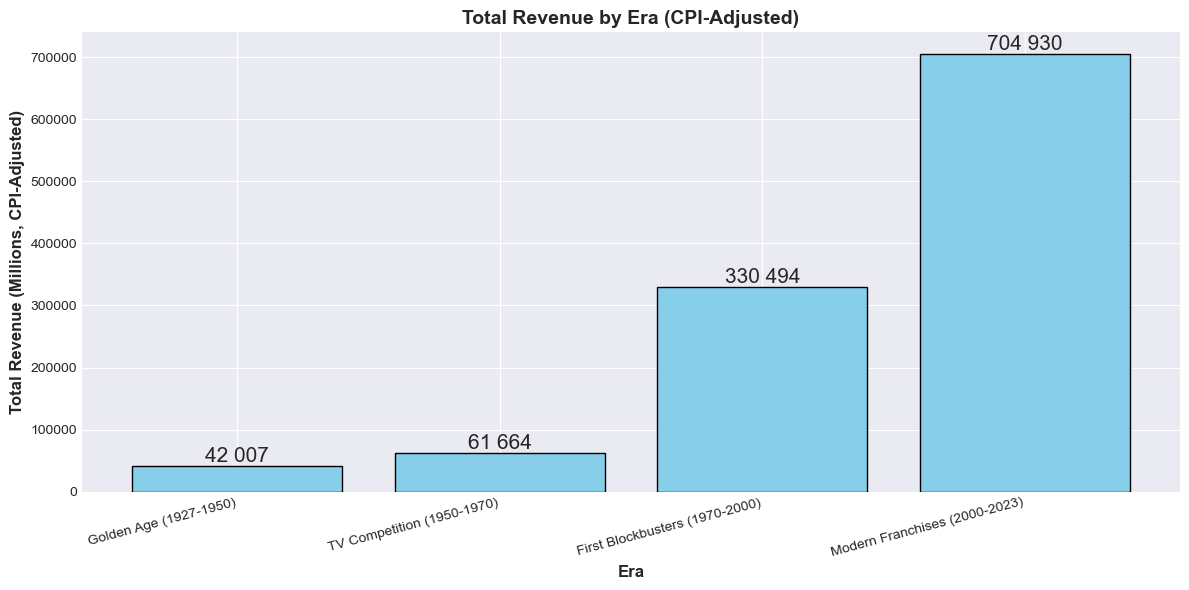

✓ Bar chart saved: viz_era_total_revenue_films.png


In [35]:
# 3. Plot bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(
    era_revenue['era'],
    era_revenue['revenue_real_M'],
    color='skyblue',
    edgecolor='black'
)

plt.title('Total Revenue by Era (CPI-Adjusted)', fontsize=14, fontweight='bold')
plt.xlabel('Era', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue (Millions, CPI-Adjusted)', fontsize=12, fontweight='bold')
plt.xticks(rotation=15, ha='right')

# 4. Add readable labels (space as thousands separator)
for bar, y in zip(bars, era_revenue['revenue_real_M']):
    if np.isfinite(y):
        label = f"{y:,.0f}".replace(",", " ")
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            label,
            ha='center',
            va='bottom',
            fontsize=15
        )

plt.tight_layout()
plt.savefig('viz_era_total_revenue_films.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Bar chart saved: viz_era_total_revenue_films.png")

### Top Genres by Film Count

In [36]:
# Count films per genre
genre_counts = (
    df_genres
    .groupby('genres', as_index=False)
    .size()
    .rename(columns={'size': 'film_count'})
    .sort_values('film_count', ascending=False)
)

top10_genres = genre_counts.head(10)

# Total number of movies (rows)
total_movies = len(df_genres)

total_str = f"{int(total_movies):,}".replace(",", " ")
print(f"Total number of film-genre combinations in dataset: {total_str}")

print("\nTop 10 Genres by Film Count:")
for _, row in top10_genres.iterrows():
    count_str = f"{int(row['film_count']):,}".replace(",", " ")
    print(f"- {row['genres']}: {count_str} films")

Total number of film-genre combinations in dataset: 17 214

Top 10 Genres by Film Count:
- Drama: 2 819 films
- Comedy: 2 331 films
- Action: 1 836 films
- Thriller: 1 664 films
- Adventure: 1 363 films
- Romance: 1 231 films
- Crime: 1 027 films
- Family: 785 films
- Science Fiction: 761 films
- Fantasy: 724 films


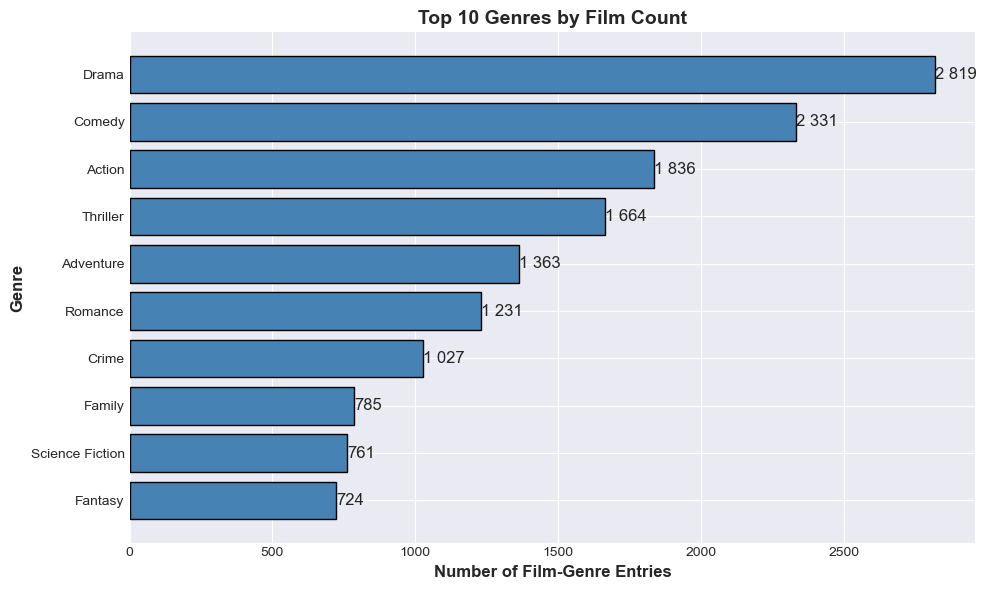

✓ Bar chart saved: viz_top10_genres_film_count.png


In [37]:
# Sort so the biggest bar is at the top
top10_genres = top10_genres.sort_values('film_count', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top10_genres['genres'],
    top10_genres['film_count'],
    color='steelblue',
    edgecolor='black'
)

plt.title('Top 10 Genres by Film Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Film-Genre Entries', fontsize=12, fontweight='bold')
plt.ylabel('Genre', fontsize=12, fontweight='bold')

# Add labels with space as thousands separator
for bar, y in zip(bars, top10_genres['film_count']):
    label = f"{int(y):,}".replace(",", " ")
    plt.text(
        y,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center',
        ha='left',
        fontsize=12
    )

plt.tight_layout()
plt.savefig('viz_top10_genres_film_count.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Bar chart saved: viz_top10_genres_film_count.png")


In [38]:
print(df_genres.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17214 entries, 0 to 17213
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   title                17214 non-null  object        
 1   genres               17214 non-null  object        
 2   release_date         17214 non-null  datetime64[ns]
 3   budget               17214 non-null  int64         
 4   revenue              17214 non-null  int64         
 5   vote_average         17214 non-null  float64       
 6   vote_count           17214 non-null  int64         
 7   popularity           17214 non-null  float64       
 8   id                   17214 non-null  int64         
 9   year                 17214 non-null  int32         
 10  cpi_index            17214 non-null  float64       
 11  budget_real_M        17214 non-null  float64       
 12  revenue_real_M       17214 non-null  float64       
 13  era                  17214 non-

### Top 10 Genres by Revenue

In [39]:
# Sum allocated revenue per genre
genre_revenue = (
    df_genres
    .groupby('genres', as_index=False)['revenue_allocated_M']
    .sum()
    .sort_values('revenue_allocated_M', ascending=False)
)

top10_genres_rev = genre_revenue.head(10)

# Total allocated CPI-adjusted revenue across all film-genre rows
total_revenue = df_genres['revenue_allocated_M'].sum()
total_str = f"{total_revenue:,.0f}".replace(",", " ")

print(f"Total CPI-adjusted allocated revenue (all genres): {total_str} M\n")

print("Top 10 Genres by CPI-adjusted Allocated Revenue (in millions):")
for _, row in top10_genres_rev.iterrows():
    value_str = f"{row['revenue_allocated_M']:,.0f}".replace(",", " ")
    print(f"- {row['genres']}: {value_str} M")


Total CPI-adjusted allocated revenue (all genres): 1 139 094 M

Top 10 Genres by CPI-adjusted Allocated Revenue (in millions):
- Action: 152 993 M
- Comedy: 148 417 M
- Drama: 146 088 M
- Adventure: 139 719 M
- Thriller: 87 675 M
- Science Fiction: 70 601 M
- Fantasy: 66 552 M
- Romance: 66 314 M
- Family: 63 954 M
- Crime: 46 489 M


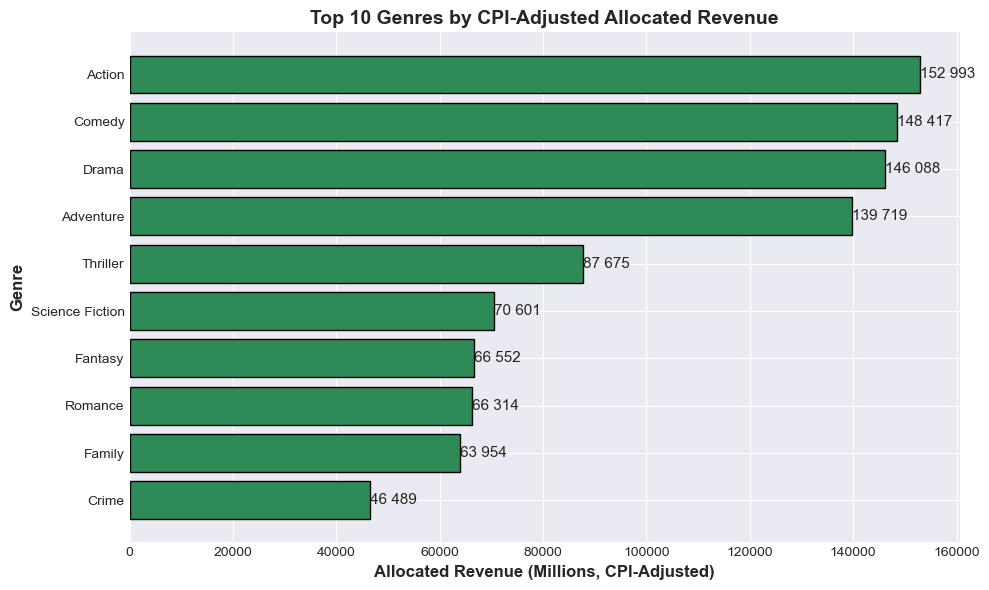

✓ Bar chart saved: viz_top10_genres_revenue.png


In [40]:
# Sort ascending so the largest bar appears at the top
top10_genres_rev = top10_genres_rev.sort_values('revenue_allocated_M', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top10_genres_rev['genres'],
    top10_genres_rev['revenue_allocated_M'],
    color='seagreen',
    edgecolor='black'
)

plt.title('Top 10 Genres by CPI-Adjusted Allocated Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Allocated Revenue (Millions, CPI-Adjusted)', fontsize=12, fontweight='bold')
plt.ylabel('Genre', fontsize=12, fontweight='bold')

# Add value labels with space as thousands separator
for bar, y in zip(bars, top10_genres_rev['revenue_allocated_M']):
    label = f"{y:,.0f}".replace(",", " ")
    plt.text(
        y,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center',
        ha='left',
        fontsize=11
    )

plt.tight_layout()
plt.savefig('viz_top10_genres_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Bar chart saved: viz_top10_genres_revenue.png")


#### Genre Market Share Heatmap Across Cinematic Eras (Based on Allocated Revenue)

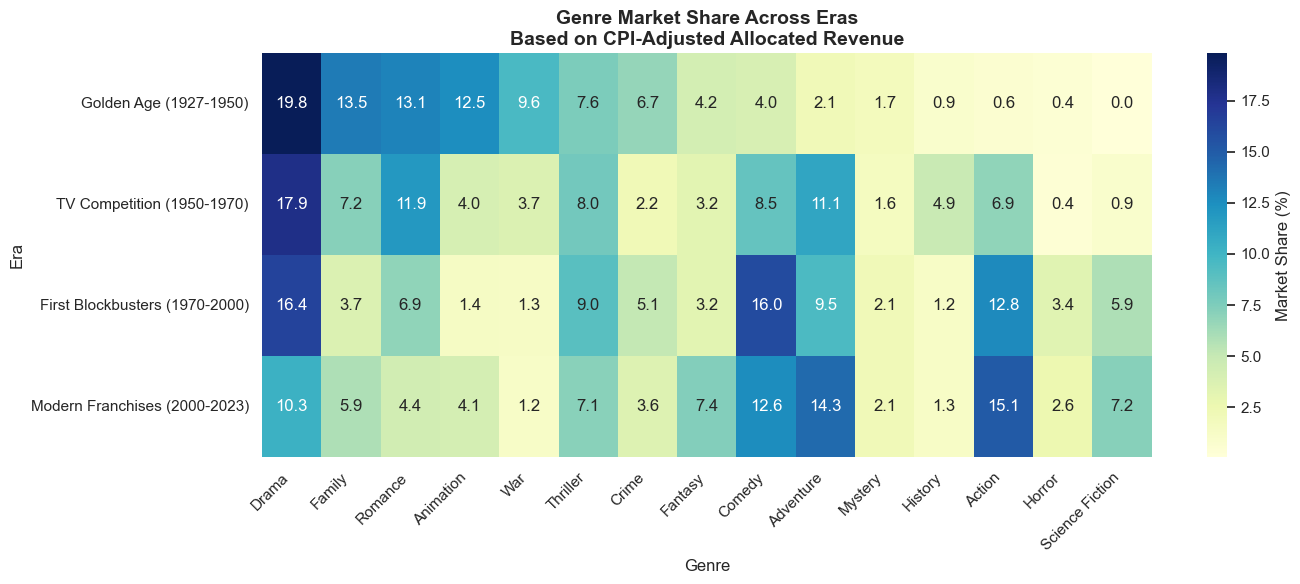


Market share by era and genre (same subset and order as heatmap):

Golden Age (1927-1950):
- Drama: 20%
- Family: 13%
- Romance: 13%
- Animation: 12%
- War: 10%
- Thriller: 8%
- Crime: 7%
- Fantasy: 4%
- Comedy: 4%
- Adventure: 2%
- Mystery: 2%
- History: 1%
- Action: 1%
- Horror: 0%
- Science Fiction: 0%

TV Competition (1950-1970):
- Drama: 18%
- Family: 7%
- Romance: 12%
- Animation: 4%
- War: 4%
- Thriller: 8%
- Crime: 2%
- Fantasy: 3%
- Comedy: 8%
- Adventure: 11%
- Mystery: 2%
- History: 5%
- Action: 7%
- Horror: 0%
- Science Fiction: 1%

First Blockbusters (1970-2000):
- Drama: 16%
- Family: 4%
- Romance: 7%
- Animation: 1%
- War: 1%
- Thriller: 9%
- Crime: 5%
- Fantasy: 3%
- Comedy: 16%
- Adventure: 9%
- Mystery: 2%
- History: 1%
- Action: 13%
- Horror: 3%
- Science Fiction: 6%

Modern Franchises (2000-2023):
- Drama: 10%
- Family: 6%
- Romance: 4%
- Animation: 4%
- War: 1%
- Thriller: 7%
- Crime: 4%
- Fantasy: 7%
- Comedy: 13%
- Adventure: 14%
- Mystery: 2%
- History: 1%
- Ac

In [41]:
df = df_genres.copy()

# 1. Total allocated revenue by era and genre
genre_era_rev = (
    df.groupby(['era', 'genres'], as_index=False)['revenue_allocated_M']
      .sum()
)

# 2. Market share (%) within each era
genre_era_rev['Market_Share_%'] = (
    genre_era_rev.groupby('era')['revenue_allocated_M']
                 .transform(lambda x: x / x.sum() * 100)
)

# 3. Optional: limit to top N genres overall
top_genres_overall = (
    genre_era_rev.groupby('genres')['revenue_allocated_M']
                 .sum()
                 .sort_values(ascending=False)
                 .head(15)          # keep in sync with your design
                 .index
)
genre_era_rev = genre_era_rev[genre_era_rev['genres'].isin(top_genres_overall)]

# 4. Pivot for heatmap
heat_data = genre_era_rev.pivot(
    index='era',
    columns='genres',
    values='Market_Share_%'
).fillna(0)

era_order = [
    "Golden Age (1927-1950)",
    "TV Competition (1950-1970)",
    "First Blockbusters (1970-2000)",
    "Modern Franchises (2000-2023)"
]
heat_data = heat_data.reindex(era_order)

# 4a. Order genres by Golden Age market share (descending)
golden_age = "Golden Age (1927-1950)"
if golden_age in heat_data.index:
    cols_sorted = (
        heat_data.loc[golden_age]
        .sort_values(ascending=False)
        .index
    )
    heat_data = heat_data[cols_sorted]

# 5. Heatmap
plt.figure(figsize=(14, 6))
sns.set(style="white")

ax = sns.heatmap(
    heat_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Market Share (%)"}
)

plt.title(
    "Genre Market Share Across Eras\n"
    "Based on CPI-Adjusted Allocated Revenue",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Era", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# 6. Text table with all visible market shares (matching the heatmap order)
print("\nMarket share by era and genre (same subset and order as heatmap):")
for era in heat_data.index:
    print(f"\n{era}:")
    row = heat_data.loc[era]
    for genre, val in row.items():
        print(f"- {genre}: {val:.0f}%")


In [42]:
# checking heatmap numbers 

df = df_genres.copy()

# 1. Total allocated revenue by era
era_totals = (
    df.groupby('era', as_index=False)['revenue_allocated_M']
      .sum()
      .rename(columns={'revenue_allocated_M': 'Total_Revenue_M'})
)

# Nice formatting
print("Total CPI-adjusted allocated revenue by era (in millions):")
for _, row in era_totals.iterrows():
    val = f"{row['Total_Revenue_M']:,.2f}".replace(",", " ")
    print(f"- {row['era']}: {val} M")

# 2. Total allocated revenue by genre
genre_totals = (
    df.groupby('genres', as_index=False)['revenue_allocated_M']
      .sum()
      .rename(columns={'revenue_allocated_M': 'Total_Revenue_M'})
      .sort_values('Total_Revenue_M', ascending=False)
)

print("\nTotal CPI-adjusted allocated revenue by genre (in millions):")
for _, row in genre_totals.iterrows():
    val = f"{row['Total_Revenue_M']:,.2f}".replace(",", " ")
    print(f"- {row['genres']}: {val} M")

Total CPI-adjusted allocated revenue by era (in millions):
- First Blockbusters (1970-2000): 330 493.50 M
- Golden Age (1927-1950): 42 006.51 M
- Modern Franchises (2000-2023): 704 929.88 M
- TV Competition (1950-1970): 61 663.61 M

Total CPI-adjusted allocated revenue by genre (in millions):
- Action: 152 992.86 M
- Comedy: 148 417.01 M
- Drama: 146 087.88 M
- Adventure: 139 718.94 M
- Thriller: 87 675.31 M
- Science Fiction: 70 601.20 M
- Fantasy: 66 552.19 M
- Romance: 66 314.05 M
- Family: 63 953.90 M
- Crime: 46 488.87 M
- Animation: 41 533.51 M
- Horror: 29 978.81 M
- Mystery: 23 098.73 M
- War: 19 177.90 M
- History: 16 492.03 M
- Music: 10 990.60 M
- Western: 8 015.44 M
- Documentary: 991.85 M
- TV Movie: 12.42 M


#### Small Multiples - Individual Genre Trajectories

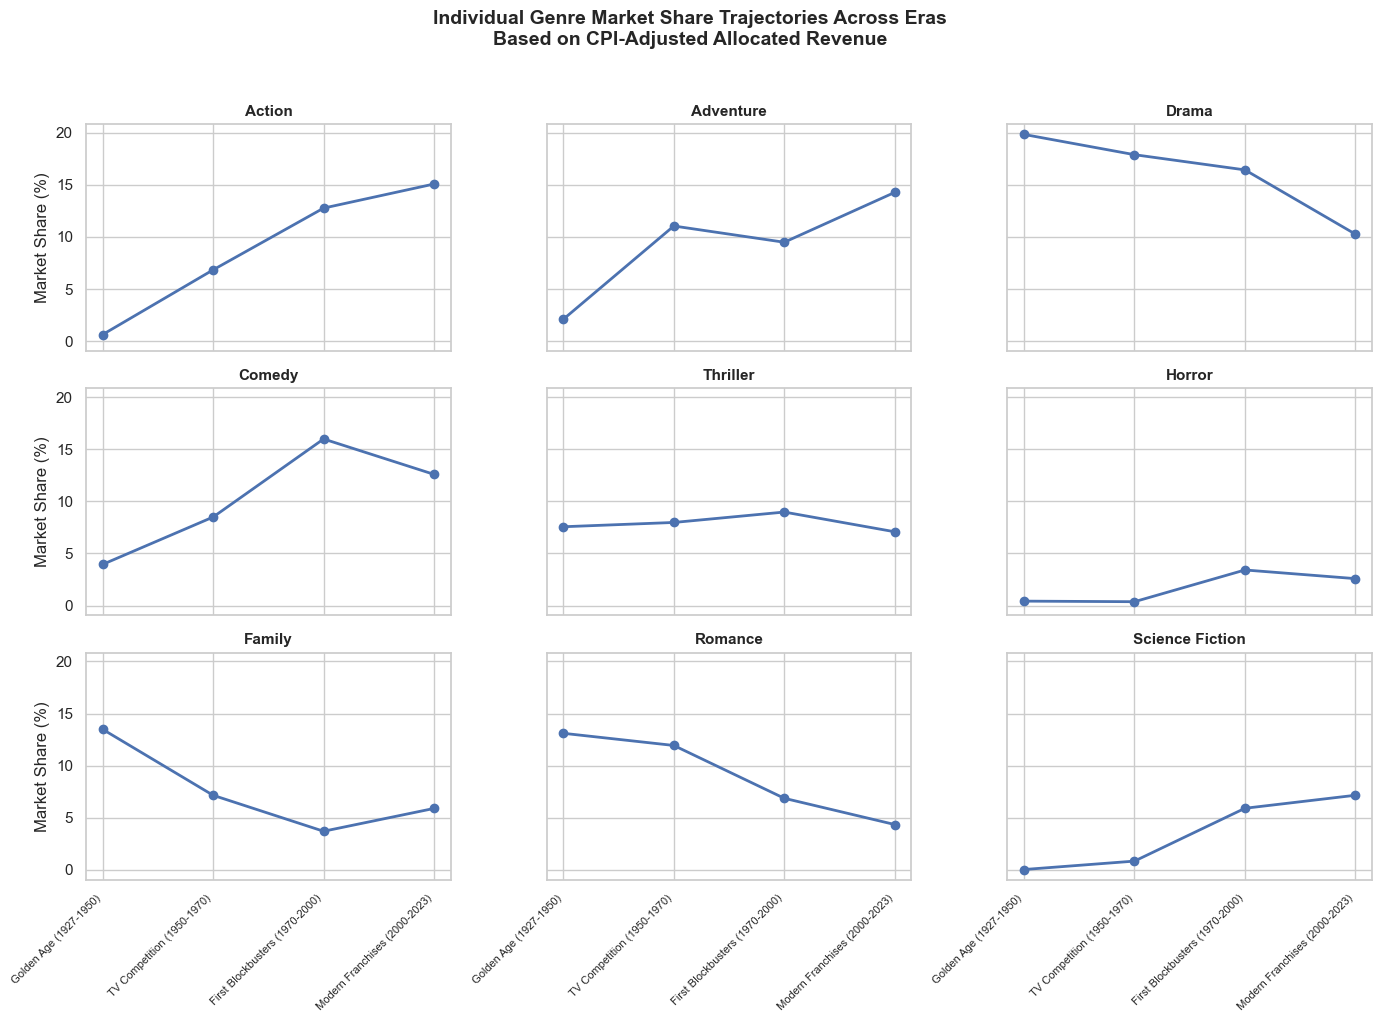

In [43]:
df = df_genres.copy()

# 1. Define eras in chronological order
era_order = [
    "Golden Age (1927-1950)",
    "TV Competition (1950-1970)",
    "First Blockbusters (1970-2000)",
    "Modern Franchises (2000-2023)"
]

# 2. Genres of interest and order
focus_genres = [
    "Action",
    "Adventure",
    "Drama",
    "Comedy",
    "Thriller",
    "Horror",
    "Family",
    "Romance",
    "Science Fiction"
]

# 3. Total allocated revenue by era and genre
genre_era_rev = (
    df.groupby(['era', 'genres'], as_index=False)['revenue_allocated_M']
      .sum()
)

# 4. Market share (%) within each era
genre_era_rev['Market_Share_%'] = (
    genre_era_rev.groupby('era')['revenue_allocated_M']
                 .transform(lambda x: x / x.sum() * 100)
)

# 5. Keep only the 9 focus genres
genre_era_focus = genre_era_rev[genre_era_rev['genres'].isin(focus_genres)].copy()

# 6. Ensure all era–genre combinations exist (fill missing with 0)
all_idx = pd.MultiIndex.from_product(
    [era_order, focus_genres],
    names=['era', 'genres']
)
genre_era_focus = (
    genre_era_focus
    .set_index(['era', 'genres'])
    .reindex(all_idx, fill_value=0)
    .reset_index()
)

# 7. Sort eras in chronological order
genre_era_focus['era'] = pd.Categorical(
    genre_era_focus['era'],
    categories=era_order,
    ordered=True
)
genre_era_focus = genre_era_focus.sort_values(['genres', 'era'])

# 8. Small multiples: one line chart per genre
sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, genre in enumerate(focus_genres):
    ax = axes[i]
    data_g = genre_era_focus[genre_era_focus['genres'] == genre]

    ax.plot(
        data_g['era'],
        data_g['Market_Share_%'],
        marker='o',
        linewidth=2
    )

    ax.set_title(genre, fontsize=11, fontweight='bold')
    ax.set_xticklabels(era_order, rotation=45, ha='right', fontsize=8)
    if i % 3 == 0:
        ax.set_ylabel('Market Share (%)')

# Hide any unused subplots (in case)
for j in range(len(focus_genres), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Individual Genre Market Share Trajectories Across Eras\n"
    "Based on CPI-Adjusted Allocated Revenue",
    fontsize=14,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()


In [44]:
print(df_genres.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17214 entries, 0 to 17213
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   title                17214 non-null  object        
 1   genres               17214 non-null  object        
 2   release_date         17214 non-null  datetime64[ns]
 3   budget               17214 non-null  int64         
 4   revenue              17214 non-null  int64         
 5   vote_average         17214 non-null  float64       
 6   vote_count           17214 non-null  int64         
 7   popularity           17214 non-null  float64       
 8   id                   17214 non-null  int64         
 9   year                 17214 non-null  int32         
 10  cpi_index            17214 non-null  float64       
 11  budget_real_M        17214 non-null  float64       
 12  revenue_real_M       17214 non-null  float64       
 13  era                  17214 non-

In [45]:
# TODO: Conduct data analysis

## Data visualisation

In [46]:
# TODO: Create at least two meaningful visualisations

In [47]:
# Example visualisation (you can modify or replace this)
# plt.figure(figsize=(10, 6))
# sns.countplot(x="Medal", data=df)
# plt.title("Distribution of Medals")
# plt.show()

In [48]:
# SUGGESTION: Use a small multiple

## Data export

In [49]:
# TODO: Save the cleaned and wrangled DataFrame to a new CSV file

In [50]:
# TODO: Ensure that you can successfully load the exported CSV file

In [51]:
# TODO: Export visualisations as image files

## Conclusion

In [52]:
# Add your conclusion here [app. 300-500 words].

## References

1. Reference 1
2. Reference 2
3. Reference 3
4. ...

*(References must be complete and contain a link to the original source; usually a DOI link.)*

## Appendices

### Appendix A

In [53]:
# Appendix A goes here

### Appendix B

In [54]:
# Appendix B goes here